**Ejercicio 1: Preparación, Limpieza y Columna Calculada** 

•	Contexto: Antes de graficar en Seaborn, necesitamos cargar nuestro dataset con la configuración regional adecuada (sep=";", encoding="utf-8"), limpiar los nombres de columnas (eliminando caracteres invisibles como el BOM), imputar los valores nulos del precio con la mediana o promedio, y crear la columna venta_total.  

•	Instrucción: Importa pandas as pd, seaborn as sns y matplotlib.pyplot as plt. 
Lee el archivo ventas_bogota_limpiar.csv, limpia los nombres de columnas, imputa los nulos de precio usando .median(), crea la columna venta_total (precio * cantidad) e imprime las primeras 3 filas.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
df = pd.read_csv('ventas_bogota_limpiar.csv', sep= ';', encoding='utf-8')
df.columns = df.columns.str.strip()

In [7]:
df['precio'] = df['precio'].fillna (df['precio'].median())
mediana_precio = df['precio']

In [8]:
df['venta_total'] = df['precio'] * df['cantidad']

print(df['venta_total'].head(3))

0    6843019.86
1    5572447.78
2    2876551.20
Name: venta_total, dtype: float64


**Ejercicio 2: Gráfico de Dispersión Multivariado (sns.scatterplot)**  

•	Contexto: Queremos analizar visualmente si existe una relación entre la cantidad de unidades vendidas y el valor total de la venta, diferenciando los puntos por la categoría del producto.  

•	Instrucción: Utiliza sns.scatterplot() asignando x="cantidad" y y="venta_total", y usa hue="categoria" para colorear las series. Añade un título descriptivo y muestra la gráfica con plt.show().


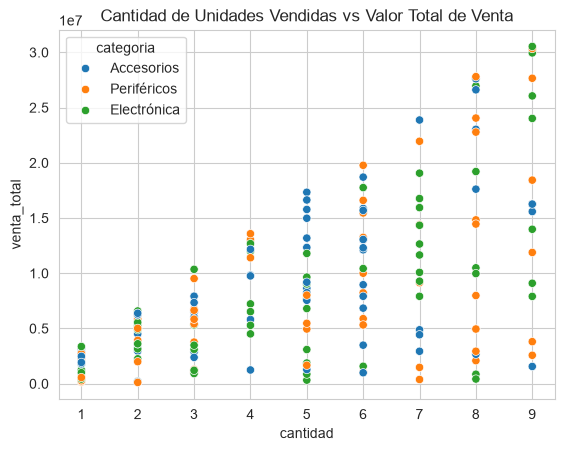

In [9]:
sns.set_style("whitegrid")
sns.scatterplot(data=df, x="cantidad", y="venta_total", hue="categoria")
plt.title("Cantidad de Unidades Vendidas vs Valor Total de Venta")
plt.show()

**Ejercicio 3: Diagrama de Caja por Ciudad (sns.boxplot)** 

•	Contexto: El equipo comercial necesita evaluar la distribución de la venta_total en cada ciudad para identificar en qué región se concentran los valores más altos o si existen valores atípicos (outliers).  

•	Instrucción: Filtra previamente el DataFrame para eliminar o rellenar los valores nulos de la columna ciudad con "No asignada". Luego, utiliza sns.boxplot() colocando x="ciudad" y y="venta_total". Añade título y etiquetas.


In [10]:
df = pd.read_csv('ventas_bogota_limpiar.csv', sep= ';', encoding='utf-8')
df 

,id_venta,fecha,producto,categoria,precio,cantidad,ciudad,metodo_pago,cliente_satisfecho
0,1,13/02/2024,Monitor,Accesorios,1140503.31,6,Barranquilla,Tarjeta,si
1,2,29/02/2024,Audífonos,Accesorios,2786223.89,2,Barranquilla,NaN,si
2,3,5/04/2024,Teclado,Accesorios,958850.40,3,Cali,NaN,No
3,4,12/05/2024,Audífonos,Periféricos,1544815.40,5,Barranquilla,Efectivo,NaN
4,5,13/05/2024,Audífonos,Periféricos,NaN,9,bogotá,tarjeta,Sí
...,...,...,...,...,...,...,...,...,...
200,11,14/04/2024,Monitor,Periféricos,618930.71,8,bogotá,NaN,NO
201,12,26/02/2024,Teclado,Periféricos,560183.09,1,Bogotá,Tarjeta,si
202,13,29/04/2024,Audífonos,Periféricos,887096.50,6,Medellín,Efectivo,Sí
203,14,23/05/2024,Mouse,Accesorios,1929054.93,1,Cali,tarjeta,si


In [11]:
df['ciudad'] = df['ciudad'].fillna('No Asignada')
df['ciudad']

0      Barranquilla
1      Barranquilla
2              Cali
3      Barranquilla
4            bogotá
           ...     
200          bogotá
201          Bogotá
202        Medellín
203            Cali
204     No Asignada
Name: ciudad, Length: 205, dtype: str

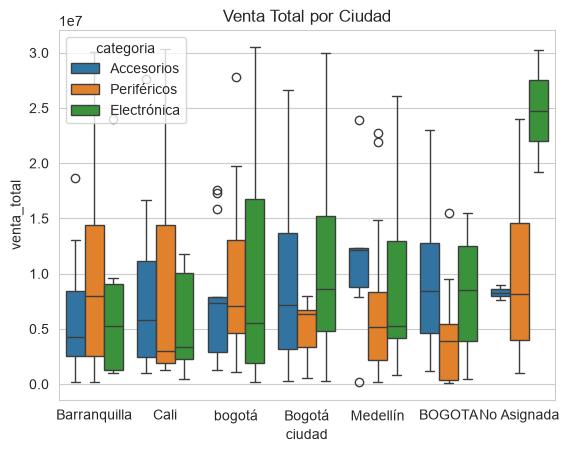

In [12]:
df['venta_total'] = df['precio'] * df['cantidad']
sns.set_style("whitegrid")
sns.boxplot(data=df, x="ciudad", y="venta_total", hue="categoria")
plt.title("Venta Total por Ciudad")
plt.show()

**Ejercicio 4: Conteo de Frecuencias por Método de Pago (sns.countplot)**  

•	Contexto: Queremos conocer de forma visual cuál es la preferencia de los clientes respecto al método de pago utilizado en las transacciones registradas.  

•	Instrucción: Rellena los valores nulos de la columna metodo_pago con "No registrado". Utiliza sns.countplot() para graficar la frecuencia de cada método de pago ordenado de mayor a menor (order=...).


In [13]:
df['metodo_pago'] = df['metodo_pago'].fillna('No Registrado')
df['metodo_pago']

0            Tarjeta
1      No Registrado
2      No Registrado
3           Efectivo
4            tarjeta
           ...      
200    No Registrado
201          Tarjeta
202         Efectivo
203          tarjeta
204          Tarjeta
Name: metodo_pago, Length: 205, dtype: str

In [14]:
# Se limpian los datos para que en la grafica no repita columnas con el mismo nombre:

df['metodo_pago'] = df['metodo_pago'].astype(str).str.strip().str.lower()
df['metodo_pago'] = df['metodo_pago'].replace({
    'tarjeta': 'Tarjeta',
    'efectivo': 'Efectivo',
    'transferencia': 'Transferencia',
    'no registrado': 'No Registrado'
})

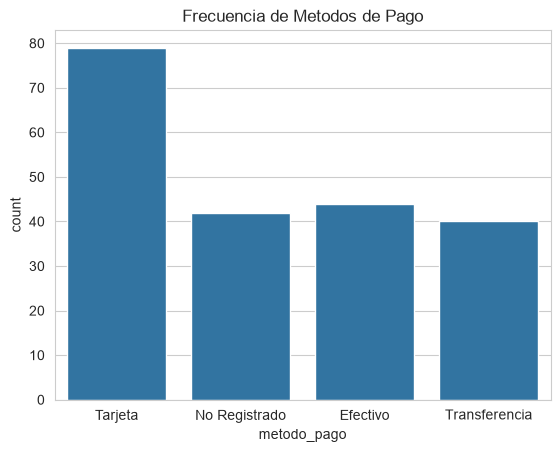

In [15]:
sns.countplot(data=df, x="metodo_pago")
plt.title("Frecuencia de Metodos de Pago")
plt.show()

**Ejercicio 5: Histograma y Curva de Densidad (sns.histplot)** 

•	Contexto: Para entender la forma estadística de nuestra variable de ingresos (venta_total), graficaremos un histograma superpuesto con una curva de densidad de probabilidad (KDE).  

•	Instrucción: Utiliza sns.histplot() con x="venta_total", activando los parámetros kde=True y bins=15. Añade líneas verticales o un título claro que refleje la distribución de los montos de venta.


In [16]:
df

,id_venta,fecha,producto,categoria,precio,cantidad,ciudad,metodo_pago,cliente_satisfecho,venta_total
0,1,13/02/2024,Monitor,Accesorios,1140503.31,6,Barranquilla,Tarjeta,si,6843019.86
1,2,29/02/2024,Audífonos,Accesorios,2786223.89,2,Barranquilla,No Registrado,si,5572447.78
2,3,5/04/2024,Teclado,Accesorios,958850.40,3,Cali,No Registrado,No,2876551.20
3,4,12/05/2024,Audífonos,Periféricos,1544815.40,5,Barranquilla,Efectivo,NaN,7724077.00
4,5,13/05/2024,Audífonos,Periféricos,NaN,9,bogotá,Tarjeta,Sí,NaN
...,...,...,...,...,...,...,...,...,...,...
200,11,14/04/2024,Monitor,Periféricos,618930.71,8,bogotá,No Registrado,NO,4951445.68
201,12,26/02/2024,Teclado,Periféricos,560183.09,1,Bogotá,Tarjeta,si,560183.09
202,13,29/04/2024,Audífonos,Periféricos,887096.50,6,Medellín,Efectivo,Sí,5322579.00
203,14,23/05/2024,Mouse,Accesorios,1929054.93,1,Cali,Tarjeta,si,1929054.93


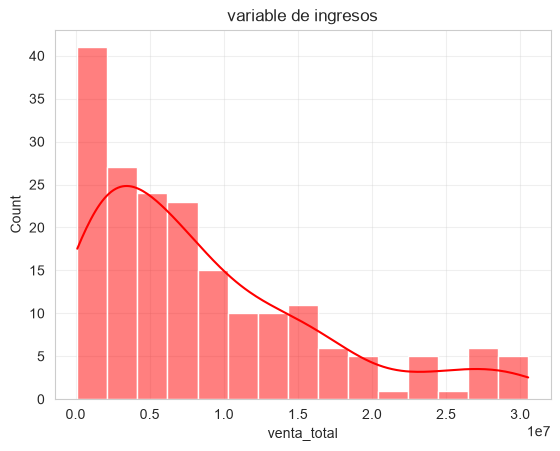

In [ ]:
import seaborn as sns
sns.histplot(data=df, x="venta_total", kde=True, color = 'red', bins = 15)
plt.xlabel('venta_total')
plt.title('variable de ingresos')
plt.grid(alpha=0.3) 
plt.show()

**Ejercicio 6: Mapa de Calor de Correlaciones Numéricas (sns.heatmap)**  

•	Contexto: Queremos analizar el grado de correlación lineal entre las variables numéricas del DataFrame (precio, cantidad y venta_total).  

•	Instrucción: Selecciona únicamente las columnas numéricas del DataFrame, calcula la matriz de correlación mediante .select_dtypes(include="number").corr(), y grafícala usando sns.heatmap() con anotaciones numéricas activadas (annot=True, fmt=".2f", esquema de color "coolwarm").


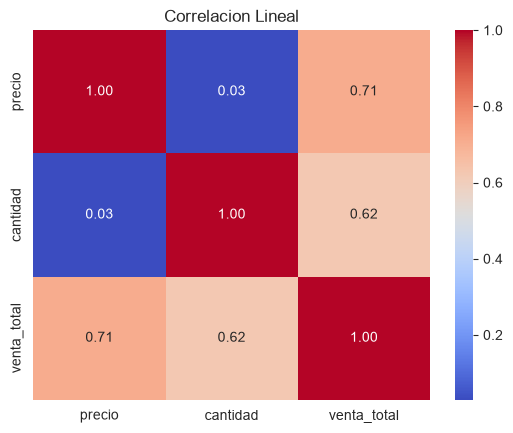

In [18]:
corr = df.select_dtypes(include="number")[["precio", "cantidad", "venta_total"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlacion Lineal")
plt.show()